# Week 3
## Milestone 2
### Manufacturing Defects

In [292]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [293]:
# Open the file

defects_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DSC 680/defects_data.csv", 
    low_memory=False
)

In [294]:
# display column names for easy reference

print(defects_df.columns)

Index(['defect_id', 'product_id', 'defect_type', 'defect_date',
       'defect_location', 'severity', 'inspection_method', 'repair_cost'],
      dtype='object')


In [295]:
defects_df.head()

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64


### Visualizations

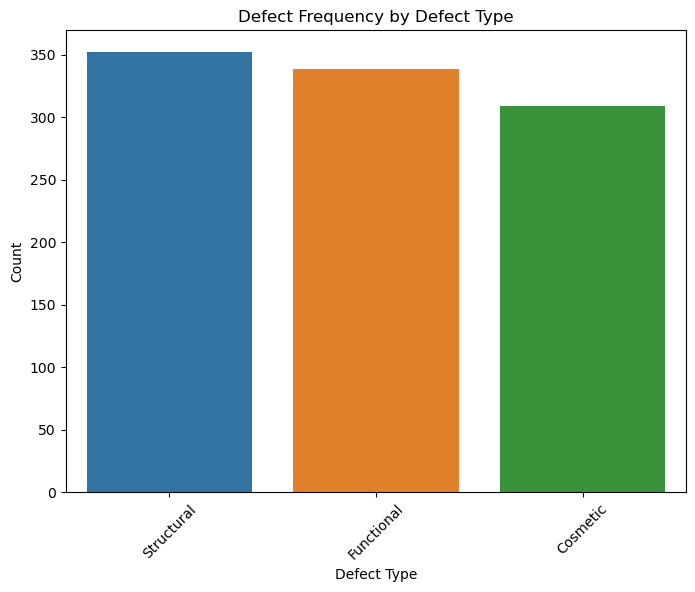

In [297]:
# Defect frequency by type

plt.figure(figsize=(8,6))
sns.countplot(data = defects_df, x = "defect_type", order = defects_df["defect_type"].value_counts().index)
plt.title("Defect Frequency by Defect Type")
plt.xlabel("Defect Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### This bar graph displays the frequency of defects by the type of defect. We see a fairly balanced count of defects in the three defect bucket types. 

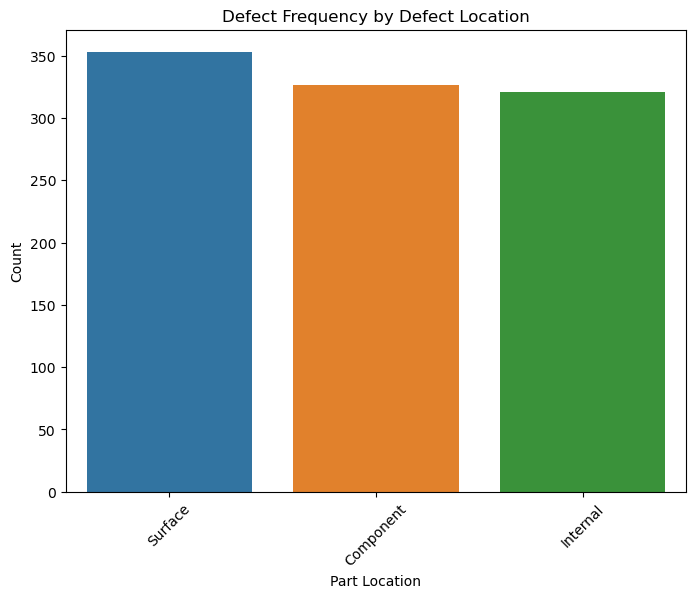

In [299]:
# Defect frequency by location

plt.figure(figsize=(8,6))
sns.countplot(data = defects_df, x = "defect_location", order = defects_df["defect_location"].value_counts().index)
plt.title("Defect Frequency by Defect Location")
plt.xlabel("Part Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### This bar graph displays the frequency of defects by location. We see the counts balanced by where the defect exists. 

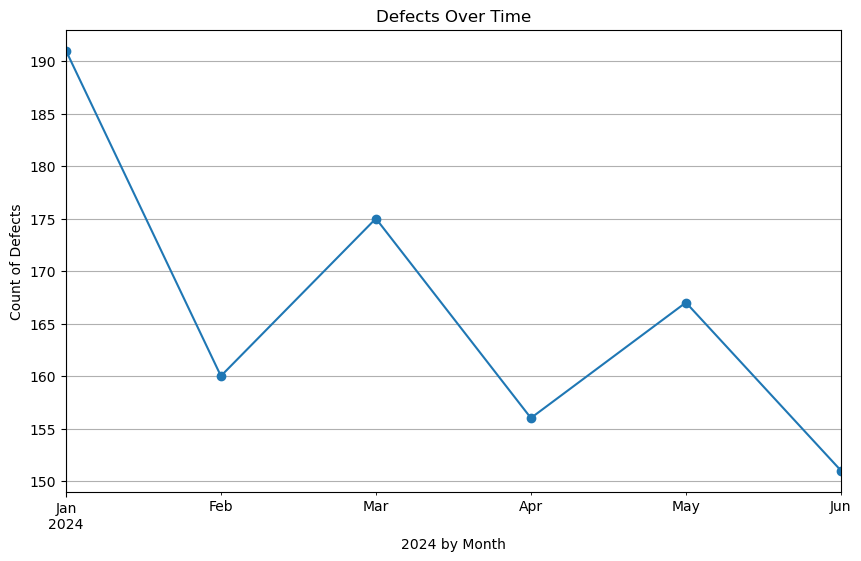

In [301]:
# Defects over time 

# Convert detection_date to datetime if not already
defects_df["defect_date"] = pd.to_datetime(defects_df["defect_date"])

# Grouped by month
monthly_defects = defects_df.groupby(defects_df["defect_date"].dt.to_period("M")).size()

plt.figure(figsize=(10,6))
monthly_defects.plot(kind="line", marker="o")
plt.title("Defects Over Time")
plt.xlabel("2024 by Month")
plt.ylabel("Count of Defects")
plt.grid(True)
plt.show()

#### This line graph displays the count of defects over the time period captured in the dataset. January saw the highest number of defects and June saw the least. 

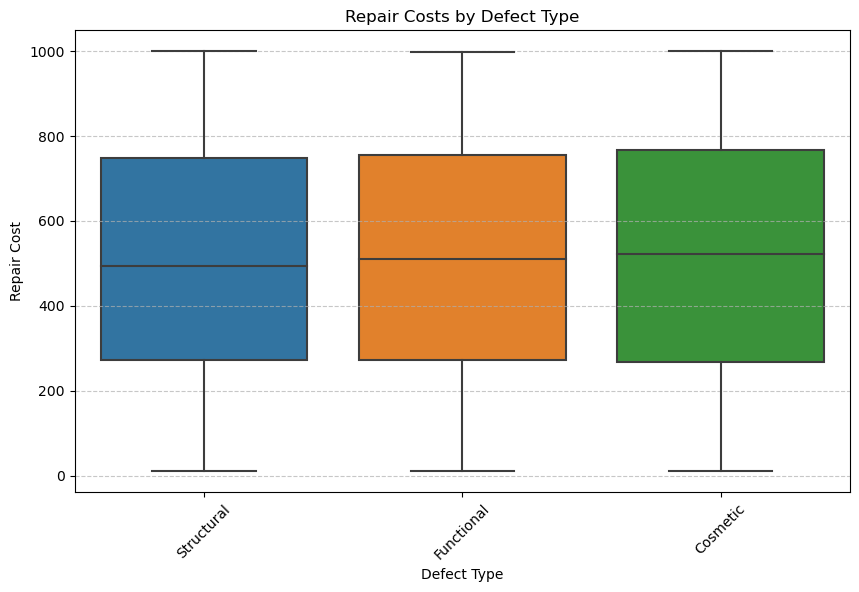

In [303]:
# Boxplot of repair costs by defect type

plt.figure(figsize=(10,6))
sns.boxplot(data=defects_df, x="defect_type", y="repair_cost")

plt.title("Repair Costs by Defect Type")
plt.xlabel("Defect Type")
plt.ylabel("Repair Cost")
plt.xticks(rotation=45)  
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()

#### This box plot illustrates the breakdown of repair costs by defect type. The amounts from each defect type are very similar, with cosmetic defects being slightly higher than the other two. 

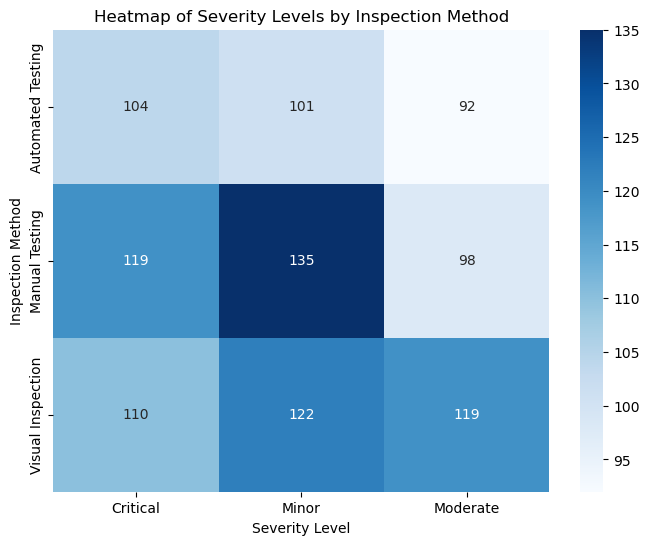

In [305]:
# Create a pivot table of counts
pivot = pd.crosstab(defects_df["inspection_method"], defects_df["severity"])

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")

plt.title("Heatmap of Severity Levels by Inspection Method")
plt.xlabel("Severity Level")
plt.ylabel("Inspection Method")
plt.show()

#### This heatmap indicates that the majority of defects fall into the minor severity category when detected through manual testing. Manual inspections are catching a lot of small issues. Also we see very few defects fall under moderate severity when detected by automated testing. Automated testing may not be as effective at detecting moderate issues.



### Predictive Analytics to estimate repair costs and defect severity.

In [308]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#### Linear Regression

In [310]:
# Linear regression model to predict repair cost
# Features: defect type, severity, and inspection method
X = defects_df[["defect_type", "severity", "inspection_method"]]
# Target
y = defects_df["repair_cost"]

# Train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the categorical features
categorical_features = ["defect_type", "severity", "inspection_method"]
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

# Linear Regression pipeline
lin_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Fit the model
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 293.8800773819144


C:\Users\rmtol\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


#### The linear regression model indicates that, on average, the predictions are off by $294 compared to the actual cost. This shows that while the model captures some patterns, repair costs likely depend more on non‑linear relationships.

#### Random Forest

In [313]:
# Features
X = defects_df[["defect_type", "defect_location", "inspection_method"]]
# Target
# 1 if critical and 0 not critical
y = (defects_df["severity"] == "Critical").astype(int)  

# Train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess categorical features
categorical_features = ["defect_type", "defect_location", "inspection_method"]
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

# Random Forest pipeline
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"))
])

# Fit the model
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.56      0.63       140
           1       0.31      0.45      0.36        60

    accuracy                           0.53       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.59      0.53      0.55       200



#### When the model predicts “Not Critical,” it’s correct 71% of the time. It correctly identifies 56% of the actual “Not Critical” cases. When the model predicts “Critical,” it’s only correct 31% of the time. It captures 45% of the actual “Critical” defects. With 53% accuracy, the model is correct half of the time. Overall, the model is much better at predicting "Not Critical" defects. This suggests that Critical defects are harder to predict. 

### Prescriptive Analytics to Recommend the Optimal Inspection Method.

In [316]:
# group by defect location and inspection method to find effectiveness
# calculate severe defect rate and average repair cost

effectiveness = defects_df.groupby(["defect_location", "inspection_method"]).agg(
    severe_detect_rate=("severity", lambda s: (s=="Critical").mean()),
    avg_cost=("repair_cost", "mean")
).reset_index()

# Rank the inspection methods by a score
# score is severe defect rate divided by average repair cost
effectiveness["score"] = effectiveness["severe_detect_rate"] / effectiveness["avg_cost"]

recommendations = effectiveness.sort_values(["defect_location", "score"], ascending=[True, False])
print(recommendations)

  defect_location  inspection_method  severe_detect_rate    avg_cost     score
1       Component     Manual Testing            0.342593  529.336759  0.000647
2       Component  Visual Inspection            0.311475  529.000656  0.000589
0       Component  Automated Testing            0.291667  541.574062  0.000539
3        Internal  Automated Testing            0.410000  463.183300  0.000885
5        Internal  Visual Inspection            0.370370  504.773333  0.000734
4        Internal     Manual Testing            0.300885  540.650265  0.000557
7         Surface     Manual Testing            0.366412  510.812519  0.000717
6         Surface  Automated Testing            0.346535  502.241980  0.000690
8         Surface  Visual Inspection            0.264463  449.251074  0.000589


#### We compared inspection methods across defect locations by examining how often they detect severe defects and the average repair cost. Then we ranked them by a cost‑effectiveness score. For components, manual testing is the best approach. For internal defects, automated testing is the most efficient approach. For surface defects, manual testing performs the best. 

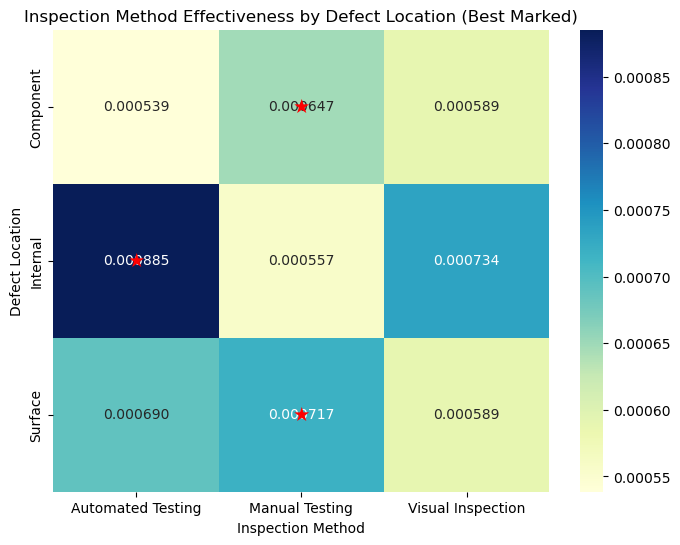

In [318]:
# Pivot the existing dataframe (effectiveness)
pivot = effectiveness.pivot(index="defect_location",
                            columns="inspection_method",
                            values="score")

# Create a mask for the maximum values per row
mask = pivot.eq(pivot.max(axis=1), axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".6f", cmap="YlGnBu")

# Overlay a star on the bext best method
for y in range(pivot.shape[0]):
    for x in range(pivot.shape[1]):
        if mask.iloc[y, x]:
            plt.text(x+0.5, y+0.5, "★", color="red", ha="center", va="center", fontsize=14)

plt.title("Inspection Method Effectiveness by Defect Location (Best Marked)")
plt.ylabel("Defect Location")
plt.xlabel("Inspection Method")
plt.show()

#### For internal defects, automated testing stands out with the highest score. For surface defects, manual testing is slightly stronger than automated testing. For component defects, manual testing edges out other methods.